# Part II: Classical Classification on CIFAR-10
**יהל מנחם ואסף בוזגלו**

In this part we train and evaluate three classical ML models on the CIFAR-10 dataset:
Logistic Regression (Softmax), Linear SVM, and KNN.
Hyperparameters are selected using **Optuna** on validation performance only.
The test set is used **once**, at the very end, after the final model is chosen.

## 0. Install & Import

In [ ]:
!pip install optuna --quiet

import pickle
import numpy as np
import os
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print('All imports successful.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 6.1 MB/s eta 0:00:00
All imports successful.


## 1. Download & Load Data

In [ ]:
!wget -q https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz
!tar -xzf cifar-10-python.tar.gz
print('CIFAR-10 downloaded and extracted.')

CIFAR-10 downloaded and extracted.


In [ ]:
def unpickle(file):
    with open(file, 'rb') as fo:
        d = pickle.load(fo, encoding='bytes')
    return d

data_dir = 'cifar-10-batches-py'

# Read class names directly from batches.meta (as documented on the official CIFAR page)
meta = unpickle(os.path.join(data_dir, 'batches.meta'))
CLASS_NAMES = [name.decode('utf-8') for name in meta[b'label_names']]
print('Classes:', CLASS_NAMES)

# Load all 5 training batches
x_list, y_list = [], []
for i in range(1, 6):
    b = unpickle(os.path.join(data_dir, f'data_batch_{i}'))
    x_list.append(b[b'data'])
    y_list.append(b[b'labels'])

X_train_full = np.concatenate(x_list).astype('float32') / 255.0
y_train_full = np.concatenate(y_list)

test_batch = unpickle(os.path.join(data_dir, 'test_batch'))
X_test_raw = test_batch[b'data'].astype('float32') / 255.0
y_test      = np.array(test_batch[b'labels'])

print(f'Train full: {X_train_full.shape}, Test: {X_test_raw.shape}')

Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Train full: (50000, 3072), Test: (10000, 3072)


## 2. Preprocessing: Split → Scale → PCA

We apply **StandardScaler** (zero mean, unit variance) followed by **PCA** to reduce the
3072-dimensional raw pixel space to a manageable number of components while retaining
most of the variance. This is standard practice for classical ML on image data and
significantly speeds up training without sacrificing much accuracy.

All transformations are **fit only on the training set** and applied to validation and test sets.

Train: 45,000  |  Val: 5,000  |  Test: 10,000
PCA with 200 components explains 94.5% of variance
Reduced shape  →  Train: (45000, 200)  Val: (5000, 200)  Test: (10000, 200)


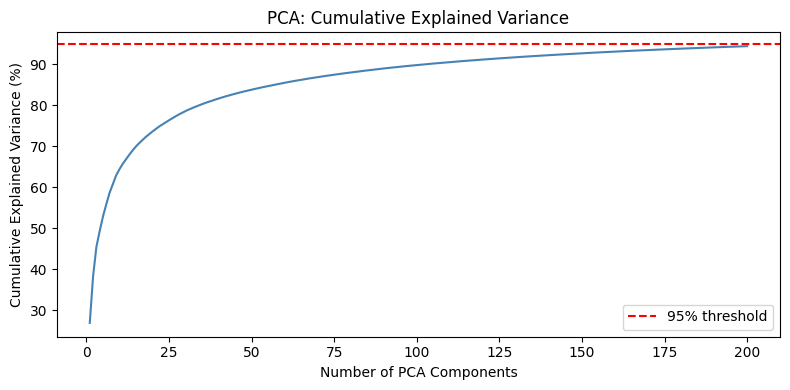

In [ ]:
# ── Train / Validation split (90 / 10) ──────────────────────────────────────
X_tr_raw, X_val_raw, y_train, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=0.10, random_state=RANDOM_STATE, stratify=y_train_full
)
print(f'Train: {X_tr_raw.shape[0]:,}  |  Val: {X_val_raw.shape[0]:,}  |  Test: {X_test_raw.shape[0]:,}')

# ── StandardScaler ──────────────────────────────────────────────────────────
scaler = StandardScaler()
X_tr_sc  = scaler.fit_transform(X_tr_raw)
X_val_sc = scaler.transform(X_val_raw)
X_te_sc  = scaler.transform(X_test_raw)

# ── PCA: keep 200 components (≈ 95 % variance) ──────────────────────────────
N_COMPONENTS = 200
pca = PCA(n_components=N_COMPONENTS, random_state=RANDOM_STATE)
X_train = pca.fit_transform(X_tr_sc)
X_val   = pca.transform(X_val_sc)
X_test  = pca.transform(X_te_sc)

explained = pca.explained_variance_ratio_.cumsum()[-1]
print(f'PCA with {N_COMPONENTS} components explains {explained*100:.1f}% of variance')
print(f'Reduced shape  →  Train: {X_train.shape}  Val: {X_val.shape}  Test: {X_test.shape}')

# ── Cumulative explained variance plot ──────────────────────────────────────
cum_var = pca.explained_variance_ratio_.cumsum()
plt.figure(figsize=(8, 4))
plt.plot(range(1, N_COMPONENTS + 1), cum_var * 100, color='steelblue')
plt.axhline(95, color='r', linestyle='--', label='95% threshold')
plt.xlabel('Number of PCA Components')
plt.ylabel('Cumulative Explained Variance (%)')
plt.title('PCA: Cumulative Explained Variance')
plt.legend()
plt.tight_layout()
plt.show()

## 3. KNN – Hyperparameter Tuning with Optuna

We use **Optuna** (TPE sampler) to search over the number of neighbours *k*.
Each trial trains on the full 45 k training set and evaluates on the validation set.
The best *k* is the one that maximises validation accuracy.

Running KNN cross-validation sweep...
  k= 1  cv_acc=0.3562 ± 0.0013
  k= 3  cv_acc=0.3418 ± 0.0019
  k= 5  cv_acc=0.3488 ± 0.0027
  k= 7  cv_acc=0.3511 ± 0.0048
  k=10  cv_acc=0.3506 ± 0.0030
  k=15  cv_acc=0.3470 ± 0.0030
  k=20  cv_acc=0.3432 ± 0.0033
  k=30  cv_acc=0.3376 ± 0.0046


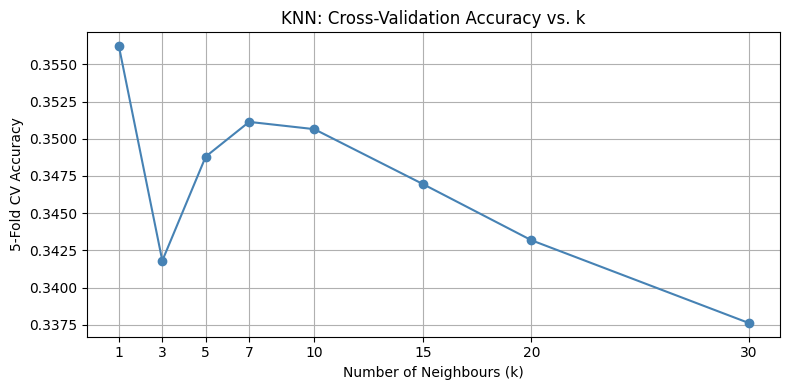


Best k from CV sweep: 1
Optuna best k: 1  →  cv_acc: 0.3562
KNN (k=1) Validation Accuracy: 0.3714


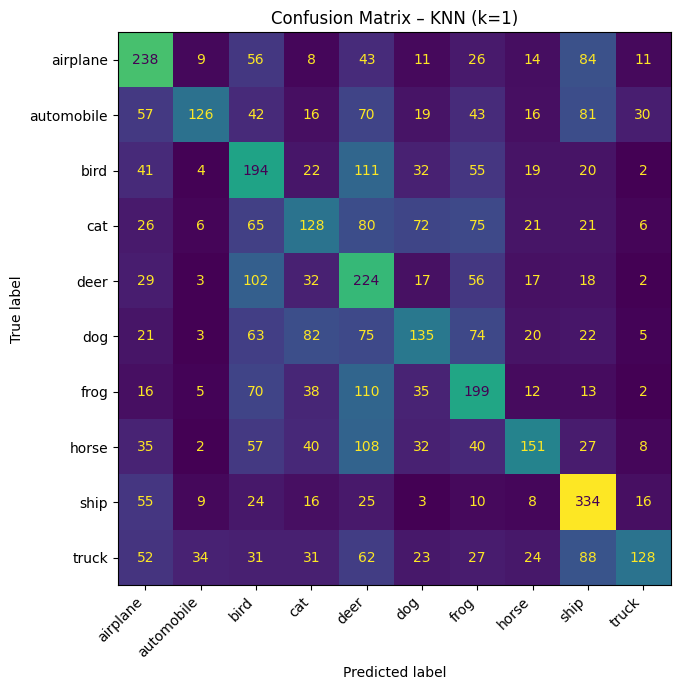

In [ ]:
from sklearn.model_selection import cross_val_score

# ── שלב 1: Sweep עם Cross-Validation (5-fold) לגרף הנדרש ─────────────────────
K_CANDIDATES = [1, 3, 5, 7, 10, 15, 20, 30]
knn_cv_accs = {}

print('Running KNN cross-validation sweep...')
for k in K_CANDIDATES:
    knn_tmp = KNeighborsClassifier(n_neighbors=k, n_jobs=-1)
    cv_scores = cross_val_score(knn_tmp, X_train, y_train, cv=5, scoring='accuracy', n_jobs=-1)
    knn_cv_accs[k] = cv_scores.mean()
    print(f'  k={k:2d}  cv_acc={cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

# גרף נדרש
plt.figure(figsize=(8, 4))
plt.plot(list(knn_cv_accs.keys()), list(knn_cv_accs.values()),
         marker='o', color='steelblue')
plt.xlabel('Number of Neighbours (k)')
plt.ylabel('5-Fold CV Accuracy')
plt.title('KNN: Cross-Validation Accuracy vs. k')
plt.xticks(K_CANDIDATES)
plt.grid(True)
plt.tight_layout()
plt.show()

best_k_manual = max(knn_cv_accs, key=knn_cv_accs.get)
print(f'\nBest k from CV sweep: {best_k_manual}')

# ── שלב 2: חיפוש עדין עם Optuna ──────────────────────────────────────────────
def knn_objective(trial):
    k = trial.suggest_int('k', 1, 30)
    model = KNeighborsClassifier(n_neighbors=k, n_jobs=-1)
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy', n_jobs=-1)
    return cv_scores.mean()

knn_study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
)
knn_study.enqueue_trial({'k': 1})
knn_study.enqueue_trial({'k': best_k_manual})
knn_study.optimize(knn_objective, n_trials=22, show_progress_bar=False)

best_k = knn_study.best_params['k']
best_knn_cv_acc = knn_study.best_value
print(f'Optuna best k: {best_k}  →  cv_acc: {best_knn_cv_acc:.4f}')

# ── שלב 3: אימון על כל X_train, הערכה על validation ─────────────────────────
best_knn = KNeighborsClassifier(n_neighbors=best_k, n_jobs=-1)
best_knn.fit(X_train, y_train)
y_pred_knn = best_knn.predict(X_val)
knn_val_accuracy = accuracy_score(y_val, y_pred_knn)
print(f'KNN (k={best_k}) Validation Accuracy: {knn_val_accuracy:.4f}')

fig, ax = plt.subplots(figsize=(9, 7))
ConfusionMatrixDisplay.from_predictions(
    y_val, y_pred_knn, display_labels=CLASS_NAMES, ax=ax, colorbar=False
)
ax.set_title(f'Confusion Matrix – KNN (k={best_k})')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
# ── Train final KNN and plot confusion matrix ─────────────────────────────────
best_knn = KNeighborsClassifier(n_neighbors=best_k, n_jobs=-1)
best_knn.fit(X_train, y_train)
y_pred_knn = best_knn.predict(X_val)
knn_val_accuracy = accuracy_score(y_val, y_pred_knn)
print(f'KNN (k={best_k}) Validation Accuracy: {knn_val_accuracy:.4f}')

fig, ax = plt.subplots(figsize=(9, 7))
ConfusionMatrixDisplay.from_predictions(
    y_val, y_pred_knn, display_labels=CLASS_NAMES, ax=ax, colorbar=False
)
ax.set_title(f'Confusion Matrix – KNN (k={best_k})')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 4. Logistic Regression – Hyperparameter Tuning with Optuna

We search over the regularisation strength *C* (log-uniform between 1e-3 and 10).
A larger *C* means less regularisation. We use the **lbfgs** solver with **multinomial** loss.

Running Logistic Regression cross-validation sweep...
  C=0.0001    cv_acc=0.4022 ± 0.0037
  C=0.001     cv_acc=0.4088 ± 0.0029
  C=0.01      cv_acc=0.4071 ± 0.0025
  C=0.1       cv_acc=0.4070 ± 0.0023
  C=1.0       cv_acc=0.4070 ± 0.0024
  C=10.0      cv_acc=0.4070 ± 0.0024


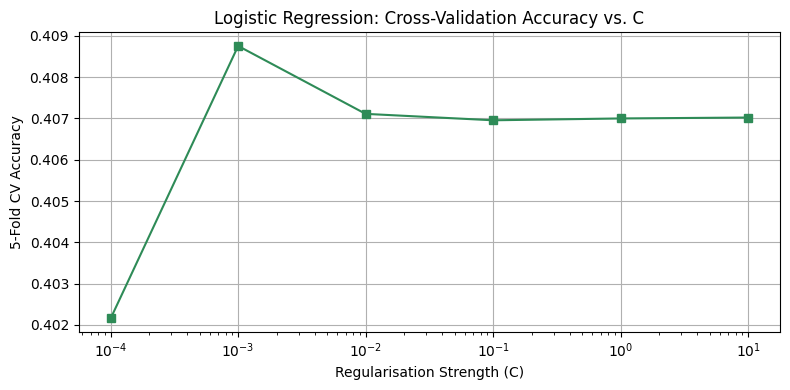


Best C from CV sweep: 0.001
Optuna best C: 0.00100  →  cv_acc: 0.4088
Logistic Regression (C=0.00100) Validation Accuracy: 0.4088


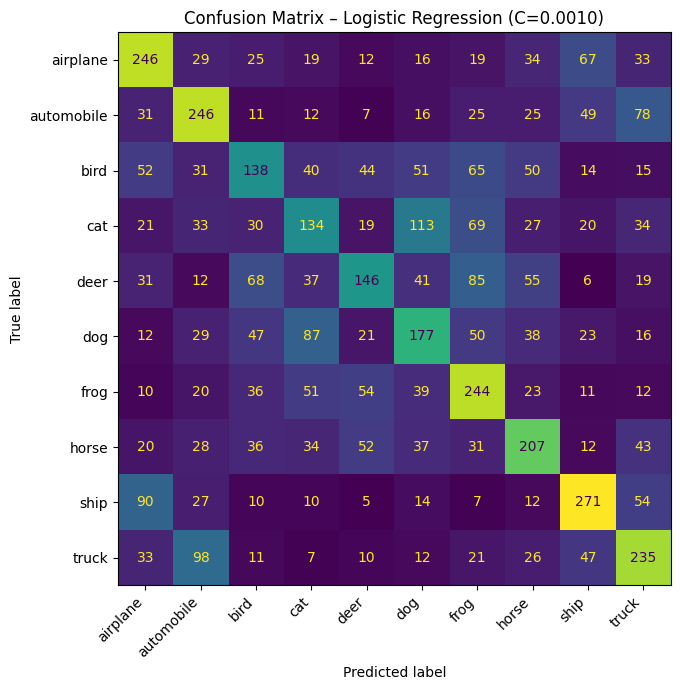

In [ ]:
from sklearn.model_selection import cross_val_score

# ── Manual sweep עם Cross-Validation לגרף הנדרש ──────────────────────────────
C_CANDIDATES = [0.0001, 0.001, 0.01, 0.1, 1.0, 10.0]
lr_cv_accs = {}

print('Running Logistic Regression cross-validation sweep...')
for c in C_CANDIDATES:
    lr_tmp = LogisticRegression(C=c, max_iter=500, solver='lbfgs',
                                multi_class='multinomial',
                                random_state=RANDOM_STATE, n_jobs=-1)
    cv_scores = cross_val_score(lr_tmp, X_train, y_train, cv=5, scoring='accuracy', n_jobs=-1)
    lr_cv_accs[c] = cv_scores.mean()
    print(f'  C={c:<8}  cv_acc={cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

# גרף נדרש
plt.figure(figsize=(8, 4))
plt.semilogx(list(lr_cv_accs.keys()), list(lr_cv_accs.values()), marker='s', color='seagreen')
plt.xlabel('Regularisation Strength (C)')
plt.ylabel('5-Fold CV Accuracy')
plt.title('Logistic Regression: Cross-Validation Accuracy vs. C')
plt.grid(True)
plt.tight_layout()
plt.show()

best_C_manual = max(lr_cv_accs, key=lr_cv_accs.get)
print(f'\nBest C from CV sweep: {best_C_manual}')

# ── חיפוש עדין עם Optuna ──────────────────────────────────────────────────────
def lr_objective(trial):
    c = trial.suggest_float('C', 1e-4, 10.0, log=True)
    model = LogisticRegression(C=c, max_iter=500, solver='lbfgs',
                               multi_class='multinomial',
                               random_state=RANDOM_STATE, n_jobs=-1)
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy', n_jobs=-1)
    return cv_scores.mean()

lr_study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
)
lr_study.enqueue_trial({'C': best_C_manual})  # מבטיח שהמנצח מה-sweep נבדק
lr_study.optimize(lr_objective, n_trials=21, show_progress_bar=False)  # 21 = 1 forced + 20 TPE

best_C_lr = lr_study.best_params['C']
best_lr_cv_acc = lr_study.best_value
print(f'Optuna best C: {best_C_lr:.5f}  →  cv_acc: {best_lr_cv_acc:.4f}')

# ── אימון מודל סופי והערכה על validation ─────────────────────────────────────
best_lr = LogisticRegression(C=best_C_lr, max_iter=1000, solver='lbfgs',
                             multi_class='multinomial',
                             random_state=RANDOM_STATE, n_jobs=-1)
best_lr.fit(X_train, y_train)
y_pred_lr = best_lr.predict(X_val)
lr_val_accuracy = accuracy_score(y_val, y_pred_lr)
print(f'Logistic Regression (C={best_C_lr:.5f}) Validation Accuracy: {lr_val_accuracy:.4f}')

fig, ax = plt.subplots(figsize=(9, 7))
ConfusionMatrixDisplay.from_predictions(
    y_val, y_pred_lr, display_labels=CLASS_NAMES, ax=ax, colorbar=False
)
ax.set_title(f'Confusion Matrix – Logistic Regression (C={best_C_lr:.4f})')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 5. Linear SVM – Hyperparameter Tuning with Optuna

We search over the regularisation strength *C* for the LinearSVC.
A smaller *C* implies stronger regularisation (wider margin, more misclassifications allowed).

Running Linear SVM manual sweep for plot...
  C=0.0001   val_acc=0.4042
  C=0.001    val_acc=0.4072
  C=0.01     val_acc=0.4078
  C=0.1      val_acc=0.4078
  C=1.0      val_acc=0.4078


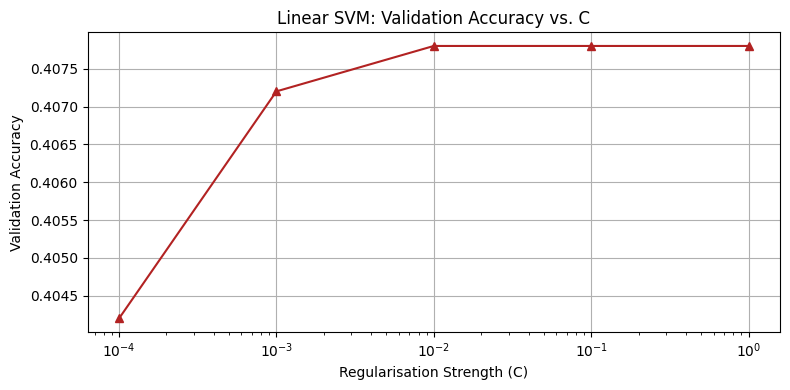

Optuna best C: 0.01127  →  val_acc: 0.4080


In [ ]:
# ── Manual sweep for plot ────────────────────────────────────────────────────
SVM_C_CANDIDATES = [0.0001, 0.001, 0.01, 0.1, 1.0]
svm_val_accs = {}

print('Running Linear SVM manual sweep for plot...')
for c in SVM_C_CANDIDATES:
    svm_tmp = LinearSVC(C=c, max_iter=2000, dual=False, random_state=RANDOM_STATE)
    svm_tmp.fit(X_train, y_train)
    acc = svm_tmp.score(X_val, y_val)
    svm_val_accs[c] = acc
    print(f'  C={c:<7}  val_acc={acc:.4f}')

# Required plot
plt.figure(figsize=(8, 4))
plt.semilogx(list(svm_val_accs.keys()), list(svm_val_accs.values()), marker='^', color='firebrick')
plt.xlabel('Regularisation Strength (C)')
plt.ylabel('Validation Accuracy')
plt.title('Linear SVM: Validation Accuracy vs. C')
plt.grid(True)
plt.tight_layout()
plt.show()

# Fine-tune with Optuna
def svm_objective(trial):
    c = trial.suggest_float('C', 1e-4, 1.0, log=True)
    model = LinearSVC(C=c, max_iter=2000, dual=False, random_state=RANDOM_STATE)
    model.fit(X_train, y_train)
    return model.score(X_val, y_val)

svm_study = optuna.create_study(direction='maximize',
                                 sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
svm_study.optimize(svm_objective, n_trials=20, show_progress_bar=False)

best_C_svm = svm_study.best_params['C']
best_svm_val_acc = svm_study.best_value
print(f'Optuna best C: {best_C_svm:.5f}  →  val_acc: {best_svm_val_acc:.4f}')

Linear SVM (C=0.01127) Validation Accuracy: 0.4080


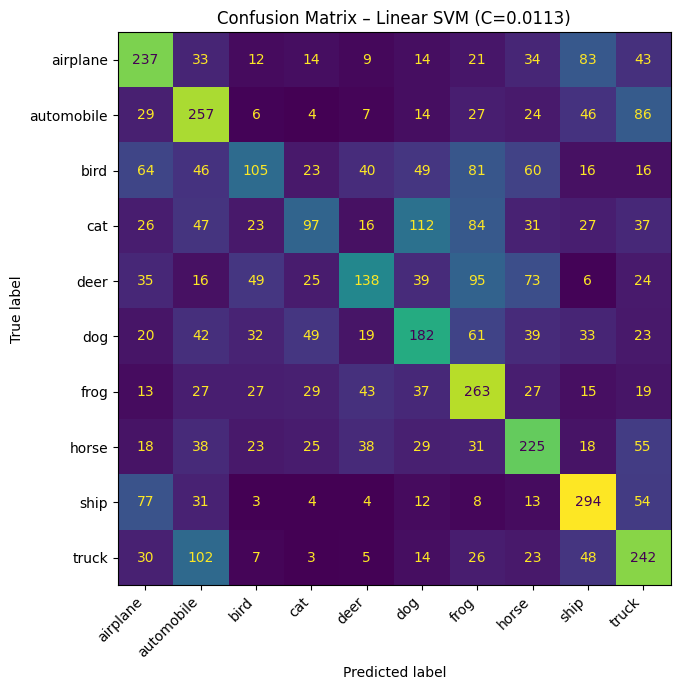

In [ ]:
# ── Train final SVM and plot confusion matrix ─────────────────────────────────
best_svm = LinearSVC(C=best_C_svm, max_iter=3000, dual=False, random_state=RANDOM_STATE)
best_svm.fit(X_train, y_train)
y_pred_svm = best_svm.predict(X_val)
svm_val_accuracy = accuracy_score(y_val, y_pred_svm)
print(f'Linear SVM (C={best_C_svm:.5f}) Validation Accuracy: {svm_val_accuracy:.4f}')

fig, ax = plt.subplots(figsize=(9, 7))
ConfusionMatrixDisplay.from_predictions(
    y_val, y_pred_svm, display_labels=CLASS_NAMES, ax=ax, colorbar=False
)
ax.set_title(f'Confusion Matrix – Linear SVM (C={best_C_svm:.4f})')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 6. Model Comparison & Final Test Evaluation

We summarise validation accuracies, choose the best model, and evaluate it **once** on the test set.

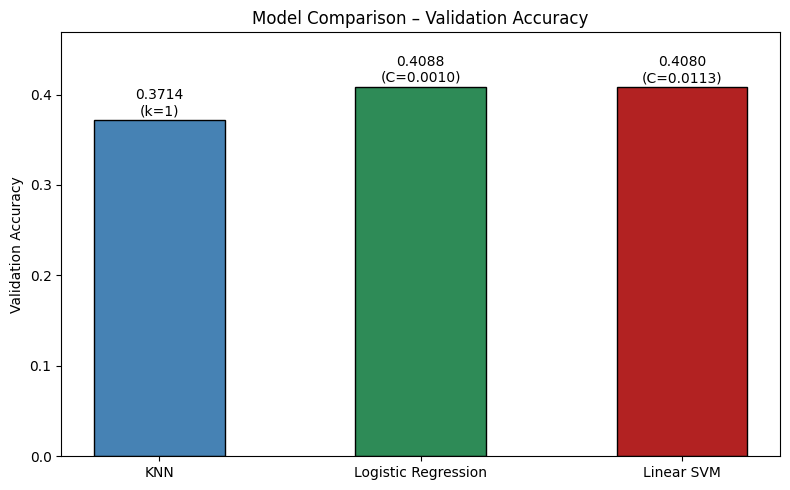


=== Validation Results Summary ===
  KNN                     acc=0.3714  best_param=k=1
  Logistic Regression     acc=0.4088  best_param=C=0.0010
  Linear SVM              acc=0.4080  best_param=C=0.0113


In [16]:
# ── Summary bar chart ────────────────────────────────────────────────────────
model_names  = ['KNN', 'Logistic Regression', 'Linear SVM']
val_accs     = [knn_val_accuracy, lr_val_accuracy, svm_val_accuracy]
best_params  = [f'k={best_k}', f'C={best_C_lr:.4f}', f'C={best_C_svm:.4f}']

colors = ['steelblue', 'seagreen', 'firebrick']
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(model_names, val_accs, color=colors, edgecolor='black', width=0.5)
for bar, acc, param in zip(bars, val_accs, best_params):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{acc:.4f}\n({param})', ha='center', va='bottom', fontsize=10)
ax.set_ylim(0, max(val_accs) + 0.06)
ax.set_ylabel('Validation Accuracy')
ax.set_title('Model Comparison – Validation Accuracy')
plt.tight_layout()
plt.show()

print('\n=== Validation Results Summary ===')
for name, acc, param in zip(model_names, val_accs, best_params):
    print(f'  {name:<22}  acc={acc:.4f}  best_param={param}')

Selected final model: Logistic Regression (val_acc=0.4088)
Running ONCE on the test set...

=== FINAL TEST ACCURACY (Logistic Regression): 40.67% ===


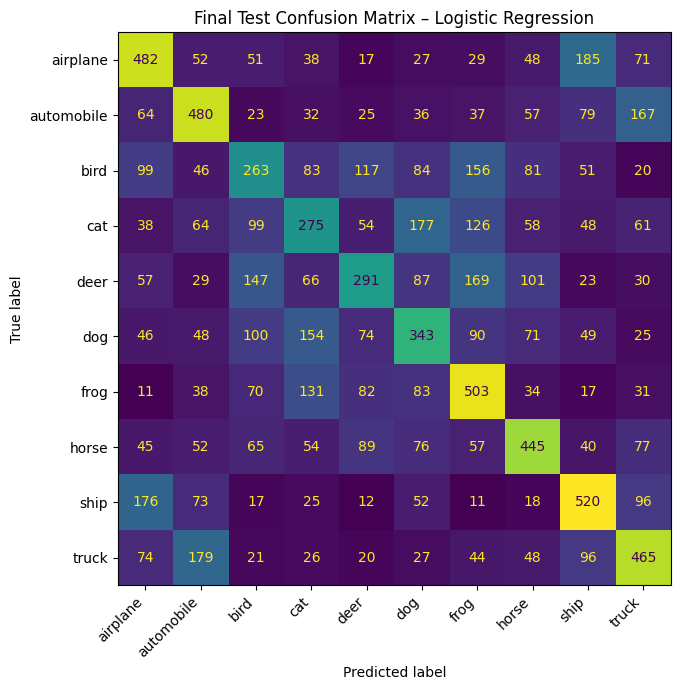

In [17]:
# ── Final model selection ────────────────────────────────────────────────────
# Choose the model with highest validation accuracy
best_idx   = int(np.argmax(val_accs))
best_model_name = model_names[best_idx]
best_model_obj  = [best_knn, best_lr, best_svm][best_idx]

print(f'Selected final model: {best_model_name} (val_acc={val_accs[best_idx]:.4f})')
print('Running ONCE on the test set...')

# ── TEST SET EVALUATION (done ONCE, at the very end) ─────────────────────────
y_pred_test = best_model_obj.predict(X_test)
test_accuracy = accuracy_score(y_test, y_pred_test)
print(f'\n=== FINAL TEST ACCURACY ({best_model_name}): {test_accuracy*100:.2f}% ===')

# Confusion matrix on test set
fig, ax = plt.subplots(figsize=(9, 7))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_test, display_labels=CLASS_NAMES, ax=ax, colorbar=False
)
ax.set_title(f'Final Test Confusion Matrix – {best_model_name}')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


=== FINAL TEST RESULTS (Logistic Regression) ===

              precision    recall  f1-score   support

    airplane     0.4414    0.4820    0.4608      1000
  automobile     0.4524    0.4800    0.4658      1000
        bird     0.3072    0.2630    0.2834      1000
         cat     0.3111    0.2750    0.2919      1000
        deer     0.3726    0.2910    0.3268      1000
         dog     0.3458    0.3430    0.3444      1000
        frog     0.4116    0.5030    0.4527      1000
       horse     0.4631    0.4450    0.4539      1000
        ship     0.4693    0.5200    0.4934      1000
       truck     0.4458    0.4650    0.4552      1000

    accuracy                         0.4067     10000
   macro avg     0.4020    0.4067    0.4028     10000
weighted avg     0.4020    0.4067    0.4028     10000

Metric                         Macro   Weighted
-----------------------------------------------
Accuracy                      0.4067     0.4067
Precision                     0.4020     0.402

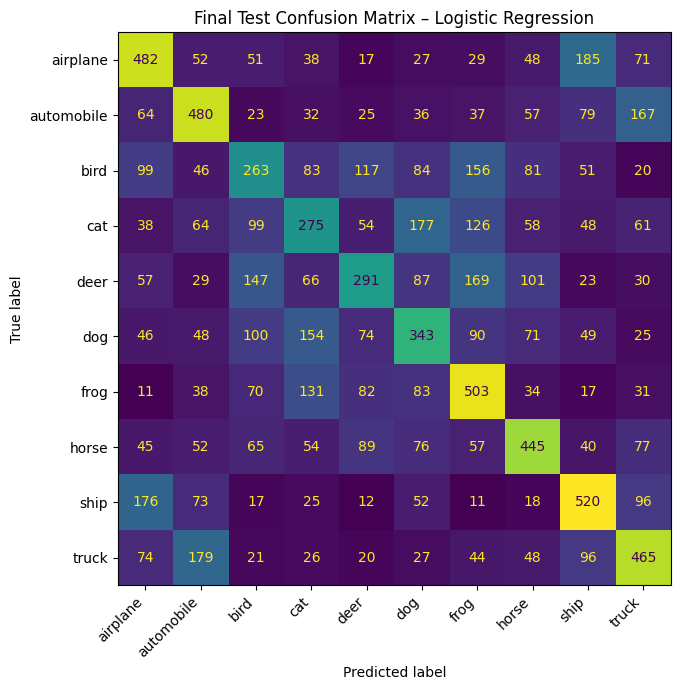

In [18]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, ConfusionMatrixDisplay
)

# ── TEST SET EVALUATION ───────────────────────────────────────────────────────
y_pred_test = best_model_obj.predict(X_test)

# ── Per-class metrics ─────────────────────────────────────────────────────────
print(f'\n=== FINAL TEST RESULTS ({best_model_name}) ===\n')
print(classification_report(
    y_test, y_pred_test,
    target_names=CLASS_NAMES,
    digits=4
))

# ── Macro / Weighted summary ──────────────────────────────────────────────────
test_accuracy  = accuracy_score(y_test, y_pred_test)
precision_mac  = precision_score(y_test, y_pred_test, average='macro')
recall_mac     = recall_score(y_test, y_pred_test, average='macro')
f1_mac         = f1_score(y_test, y_pred_test, average='macro')

precision_w    = precision_score(y_test, y_pred_test, average='weighted')
recall_w       = recall_score(y_test, y_pred_test, average='weighted')
f1_w           = f1_score(y_test, y_pred_test, average='weighted')

print(f"{'Metric':<25} {'Macro':>10} {'Weighted':>10}")
print("-" * 47)
print(f"{'Accuracy':<25} {test_accuracy:>10.4f} {test_accuracy:>10.4f}")
print(f"{'Precision':<25} {precision_mac:>10.4f} {precision_w:>10.4f}")
print(f"{'Recall':<25} {recall_mac:>10.4f} {recall_w:>10.4f}")
print(f"{'F1 Score':<25} {f1_mac:>10.4f} {f1_w:>10.4f}")

# ── Confusion Matrix ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 7))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_test,
    display_labels=CLASS_NAMES,
    ax=ax, colorbar=False
)
ax.set_title(f'Final Test Confusion Matrix – {best_model_name}')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()